# H8 — RT Slowdown (H8.1) & Mediation Analysis (H8.2)

**H8.1 Test:** Mixed-Model ANOVA on Encoding RT (Pre vs Post)  
**H8.1 Question:** Are participants slower to encode items after a boundary?  

**H8.2 Test:** Bootstrapped Mediation (500 resamples)  
**H8.2 Question:** Does the RT slowdown *cause* the change in LDI?  
**Causal chain:** Boundary position → Encoding RT → LDI

In [1]:
import warnings
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def _header(title, width=75):
    print("\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)

def _get_p(row):
    for c in row.index:
        if c in ("p-unc", "p-val", "p_val", "p_unc", "p"):
            return float(row[c])
    raise KeyError(f"No p-value column. Available: {list(row.index)}")

def _get_corr_p(cor_df):
    for c in cor_df.columns:
        if c in ("p-val", "p_val", "pval", "p"):
            return float(cor_df[c].values[0])
    raise KeyError(f"No corr p column. Available: {list(cor_df.columns)}")

def _sig(p):
    return "✅ Significant" if p < 0.05 else "❌ Not Significant"


In [3]:
CSV_PATH = "compiled_preprocessed.csv"   # <-- change this to your file path

df = pd.read_csv(CSV_PATH)

# Handle naming differences across preprocess versions.
col_candidates = {
    "participant": ["participant_uid", "participant_id", "Participant_ID"],
    "condition": ["condition", "Condition"],
    "trial_type": ["trial_type", "Trial_Type"],
    "response": ["user_response", "response", "User_Response"],
    "position": ["boundary_position", "Boundary_Position"],
    "rt": ["encoding_RT", "Encoding_RT", "encoding_rt", "Encoding_rt", "RT_encoding", "RT"],
}

resolved = {}
for key, candidates in col_candidates.items():
    resolved[key] = next((c for c in candidates if c in df.columns), None)

required_keys = ["participant", "condition", "trial_type", "response", "position"]
missing = [k for k in required_keys if resolved[k] is None]
if missing:
    raise ValueError(f"Missing required columns for {missing}. Found columns: {list(df.columns)}")

if resolved["rt"] is not None:
    df["Encoding_RT"] = pd.to_numeric(df[resolved["rt"]], errors="coerce")
else:
    df["Encoding_RT"] = np.nan
    print("Warning: No encoding RT column found; Encoding_RT set to NaN.")

pid_col = resolved["participant"]
cond_col = resolved["condition"]
trial_col = resolved["trial_type"]
resp_col = resolved["response"]
pos_col = resolved["position"]

df[cond_col] = df[cond_col].astype(str).str.strip()

# ── Global rates (1 row per participant) ─────────────────────────────────────
g_records = []
for uid, g in df.groupby(pid_col):
    cond    = g[cond_col].iloc[0]
    foils   = g[g[trial_col] == "Foil"]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    fa_t = (foils[resp_col]   == "Target").mean() if len(foils)   > 0 else 0.0
    fa_l = (foils[resp_col]   == "Lure"  ).mean() if len(foils)   > 0 else 0.0
    hit  = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    sim  = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    g_records.append({
        "participant_uid": uid, "condition": cond,
        "FA_Target": fa_t, "FA_Lure": fa_l,
        "Hit_Rate": hit,   "Sim_Rate": sim,
        "REC": hit - fa_t, "LDI": sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
global_df = pd.DataFrame(g_records)
global_df.dropna(subset=["REC", "LDI"], inplace=True)

# ── Position-specific rates ───────────────────────────────────────────────────
p_records = []
pos_trials = df[df[pos_col].isin(["Pre", "Mid", "Post"])]
for (uid, pos), g in pos_trials.groupby([pid_col, pos_col]):
    cond    = g[cond_col].iloc[0]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    pos_hit = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    pos_sim = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    fa_row  = global_df[global_df["participant_uid"] == uid]
    fa_t    = float(fa_row["FA_Target"].values[0]) if len(fa_row) > 0 else 0.0
    fa_l    = float(fa_row["FA_Lure"  ].values[0]) if len(fa_row) > 0 else 0.0
    p_records.append({
        "participant_uid": uid, "condition": cond,
        "boundary_position": pos,
        "REC": pos_hit - fa_t, "LDI": pos_sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
position_df = pd.DataFrame(p_records)
counts = position_df.groupby("participant_uid")["boundary_position"].nunique()
valid  = counts[counts == 3].index
position_df = position_df[position_df["participant_uid"].isin(valid)].copy()
position_df.dropna(subset=["REC", "LDI"], inplace=True)

print(f"Global subjects                              : {len(global_df)}")
print(f"Position subjects (balanced, 3 positions)    : {position_df['participant_uid'].nunique()}")


Global subjects                              : 160
Position subjects (balanced, 3 positions)    : 160


In [4]:
# ── H8.1: RT Slowdown — Mixed ANOVA Pre vs Post ───────────────────────────────
_header("H8.1: RT Slowdown — Mixed ANOVA on Encoding_RT (Pre vs Post)")

rt_df = position_df[position_df["boundary_position"].isin(["Pre","Post"])].copy()
rt_df = rt_df.dropna(subset=["Encoding_RT"])
rt_counts   = rt_df.groupby("participant_uid")["boundary_position"].nunique()
rt_balanced = rt_counts[rt_counts == 2].index
rt_df       = rt_df[rt_df["participant_uid"].isin(rt_balanced)].copy()

print(f"  Subjects with valid RT for both Pre & Post : {len(rt_balanced)}")
print( "  DV : Encoding_RT (ms)\n")

if len(rt_balanced) >= 3:
    mix_rt = pg.mixed_anova(data=rt_df, dv="Encoding_RT",
                             within="boundary_position", between="condition",
                             subject="participant_uid")
    for _, row in mix_rt.iterrows():
        src   = str(row["Source"]).replace("*","×")
        p_val = _get_p(row)
        print(f"  {src:<35} | F = {row['F']:>7.3f}   p = {p_val:>8.4f}   {_sig(p_val)}")
else:
    print("  ⚠️  Not enough RT data — skipping.")

# ── H8.2: Bootstrapped Mediation Analysis ────────────────────────────────────
_header("H8.2: Mediation — Boundary Position → Encoding_RT → LDI")
print("  Causal chain: boundary_position (Pre=0 / Post=1)  →  Encoding_RT  →  LDI\n")

med_df = rt_df.copy()
med_df["Pos_Num"] = med_df["boundary_position"].map({"Pre": 0, "Post": 1})
med_df = med_df.dropna(subset=["Pos_Num","Encoding_RT","LDI"])

print(f"  X = Pos_Num   M = Encoding_RT   Y = LDI")
print(f"  Observations : {len(med_df)}   Bootstraps : 500\n")

med_results = None
if len(med_df) >= 10:
    med_results = pg.mediation_analysis(data=med_df, x="Pos_Num", m="Encoding_RT",
                                         y="LDI", n_boot=500, seed=42)
    for _, row in med_results.iterrows():
        path = row["path"]
        pval = row["pval"]
        print(f"  {path:<20} | coef = {row['coef']:>8.4f}   p = {pval:>6.4f}   {_sig(pval)}")
        if path == "Indirect":
            print(f"  {'':20}   → {'✅ MEDIATION CONFIRMED' if pval < 0.05 else '❌ NO MEDIATION'}")
else:
    print("  ⚠️  Not enough data for mediation — skipping.")



═══════════════════════════════════════════════════════════════════════════
  H8.1: RT Slowdown — Mixed ANOVA on Encoding_RT (Pre vs Post)
═══════════════════════════════════════════════════════════════════════════
  Subjects with valid RT for both Pre & Post : 160
  DV : Encoding_RT (ms)

  condition                           | F =   3.774   p =   0.0251   ✅ Significant
  boundary_position                   | F =   0.734   p =   0.3928   ❌ Not Significant
  Interaction                         | F =   0.134   p =   0.8744   ❌ Not Significant

═══════════════════════════════════════════════════════════════════════════
  H8.2: Mediation — Boundary Position → Encoding_RT → LDI
═══════════════════════════════════════════════════════════════════════════
  Causal chain: boundary_position (Pre=0 / Post=1)  →  Encoding_RT  →  LDI

  X = Pos_Num   M = Encoding_RT   Y = LDI
  Observations : 320   Bootstraps : 500

  Encoding_RT ~ X      | coef =   0.0307   p = 0.7734   ❌ Not Significant
  Y ~ E

## Visualizations
Setup shared palette and ordering for all plots.

In [5]:
rt_order = ["Pre", "Post"]
cond_order = sorted(rt_df["condition"].unique())
palette = sns.color_palette("Set2", len(cond_order))
cond_colors = dict(zip(cond_order, palette))

### 1. Box + Violin: Encoding RT Pre vs Post
Distribution of encoding RT values at Pre and Post boundary positions, by condition.

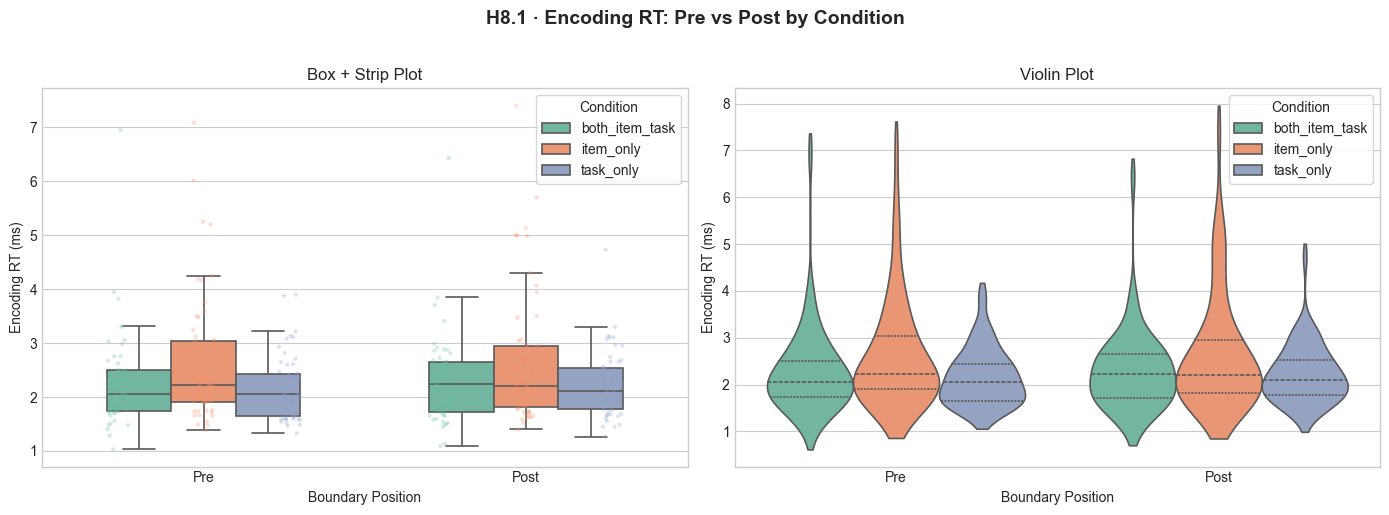

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("H8.1 · Encoding RT: Pre vs Post by Condition",
             fontsize=14, fontweight="bold", y=1.02)

# Left: Box + strip
ax = axes[0]
sns.boxplot(data=rt_df, x="boundary_position", y="Encoding_RT",
            hue="condition", order=rt_order, hue_order=cond_order,
            palette=cond_colors, ax=ax, showfliers=False,
            linewidth=1.2, width=0.6)
sns.stripplot(data=rt_df, x="boundary_position", y="Encoding_RT",
              hue="condition", order=rt_order, hue_order=cond_order,
              palette=cond_colors, ax=ax, dodge=True,
              alpha=0.3, size=3, jitter=True, legend=False)
ax.set_title("Box + Strip Plot", fontsize=12)
ax.set_xlabel("Boundary Position")
ax.set_ylabel("Encoding RT (ms)")
handles, labels = ax.get_legend_handles_labels()
n = len(cond_order)
ax.legend(handles[:n], labels[:n], title="Condition", frameon=True, loc="best")

# Right: Violin
ax = axes[1]
sns.violinplot(data=rt_df, x="boundary_position", y="Encoding_RT",
               hue="condition", order=rt_order, hue_order=cond_order,
               palette=cond_colors, ax=ax, inner="quartile",
               linewidth=1.2, cut=1, density_norm="width")
ax.set_title("Violin Plot", fontsize=12)
ax.set_xlabel("Boundary Position")
ax.set_ylabel("Encoding RT (ms)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:n], labels[:n], title="Condition", frameon=True, loc="best")

plt.tight_layout()
plt.show()

### 2. Paired Line Plot: Per-Participant RT Change
Each thin line shows one participant's RT change from Pre to Post. Bold lines show condition means.

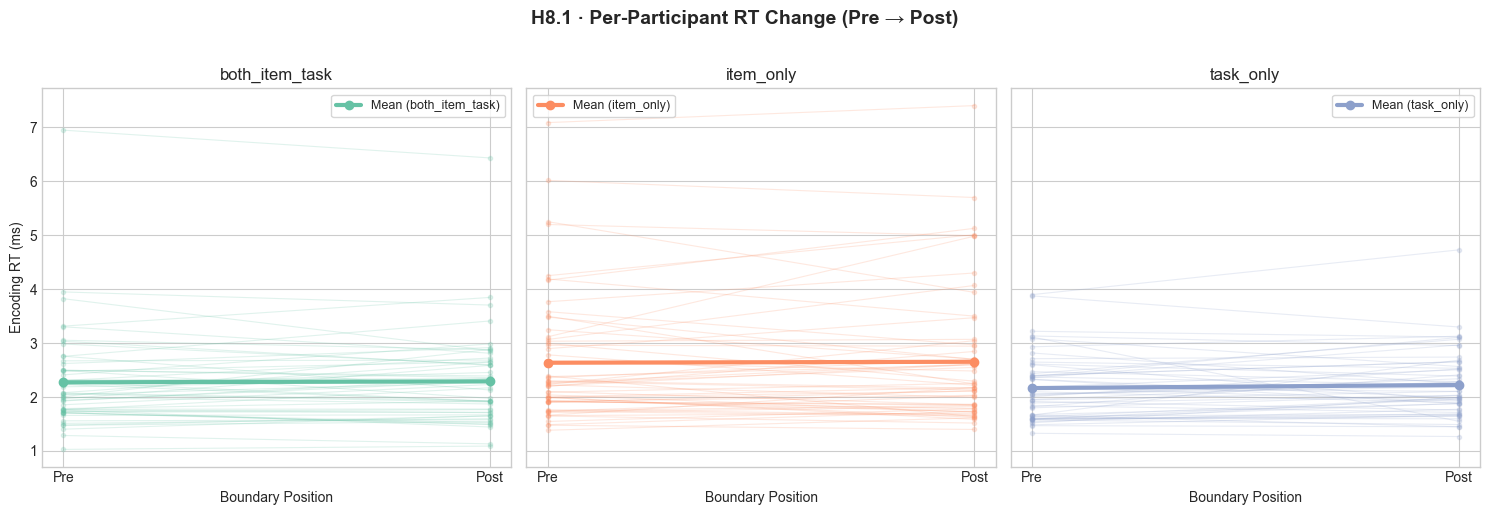

In [7]:
fig, axes = plt.subplots(1, len(cond_order), figsize=(5 * len(cond_order), 5), sharey=True)
fig.suptitle("H8.1 · Per-Participant RT Change (Pre → Post)",
             fontsize=14, fontweight="bold", y=1.02)

if len(cond_order) == 1:
    axes = [axes]

for i, cond in enumerate(cond_order):
    ax = axes[i]
    cond_sub = rt_df[rt_df["condition"] == cond]
    for uid in cond_sub["participant_uid"].unique():
        p_sub = cond_sub[cond_sub["participant_uid"] == uid].set_index("boundary_position").reindex(rt_order)
        if p_sub["Encoding_RT"].notna().all():
            ax.plot([0, 1], p_sub["Encoding_RT"].values, alpha=0.2, linewidth=0.8,
                    color=cond_colors[cond], marker="o", markersize=3)
    # overlay mean
    means = cond_sub.groupby("boundary_position")["Encoding_RT"].mean().reindex(rt_order)
    ax.plot([0, 1], means.values, marker="o", linewidth=3,
            color=cond_colors[cond], zorder=5, label=f"Mean ({cond})")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(rt_order)
    ax.set_title(f"{cond}", fontsize=12)
    ax.set_xlabel("Boundary Position")
    if i == 0:
        ax.set_ylabel("Encoding RT (ms)")
    ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

### 3. Grouped Bar Chart: Mean RT ± SEM
Side-by-side bar comparison of mean Encoding RT across boundary positions and conditions.

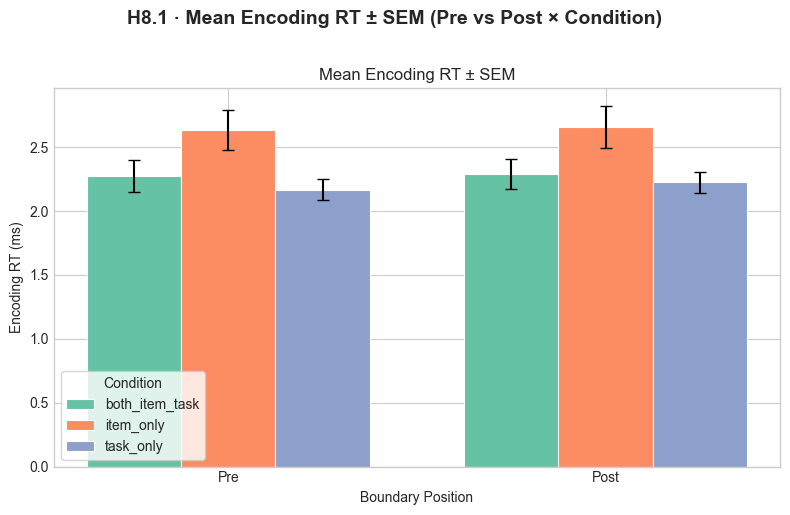

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("H8.1 · Mean Encoding RT ± SEM (Pre vs Post × Condition)",
             fontsize=14, fontweight="bold", y=1.02)

summary = (
    rt_df.groupby(["condition", "boundary_position"])["Encoding_RT"]
    .agg(["mean", "sem"])
    .reset_index()
)
bar_width = 0.25
x_positions = np.arange(len(rt_order))
for j, cond in enumerate(cond_order):
    sub = summary[summary["condition"] == cond].set_index("boundary_position").reindex(rt_order)
    ax.bar(x_positions + j * bar_width, sub["mean"].values,
           width=bar_width, yerr=sub["sem"].values, capsize=4,
           label=cond, color=cond_colors[cond], edgecolor="white", linewidth=0.8)
ax.set_xticks(x_positions + bar_width * (len(cond_order) - 1) / 2)
ax.set_xticklabels(rt_order)
ax.set_title("Mean Encoding RT ± SEM", fontsize=12)
ax.set_xlabel("Boundary Position")
ax.set_ylabel("Encoding RT (ms)")
ax.legend(title="Condition", frameon=True, loc="best")

plt.tight_layout()
plt.show()

### 4. Scatter + Regression: RT vs LDI (by Condition)
Encoding RT plotted against LDI for the mediation sample, with an overall regression line.

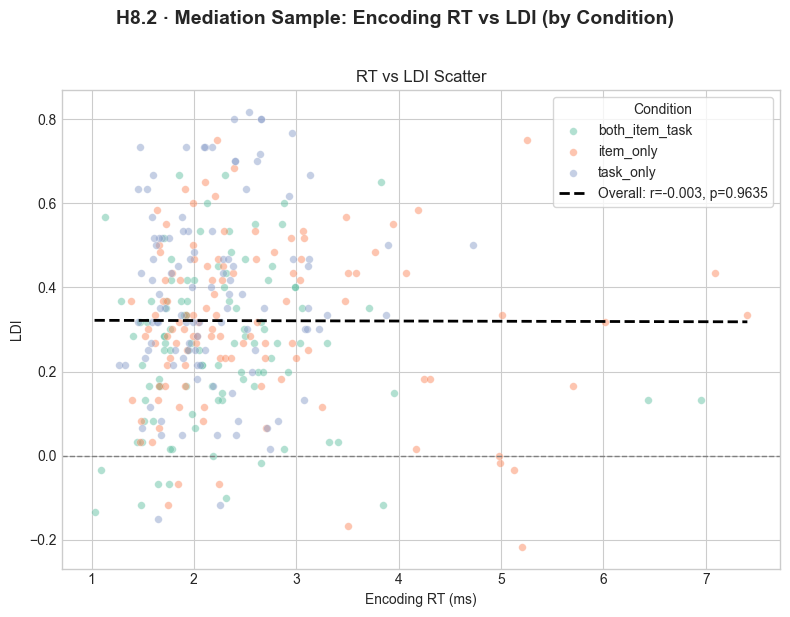

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("H8.2 · Mediation Sample: Encoding RT vs LDI (by Condition)",
             fontsize=14, fontweight="bold", y=1.02)

for cond in cond_order:
    sub = med_df[med_df["condition"] == cond]
    ax.scatter(sub["Encoding_RT"], sub["LDI"], alpha=0.5, s=30,
               color=cond_colors[cond], label=cond, edgecolors="white", linewidth=0.3)

# Overall regression
if len(med_df) >= 2 and med_df["Encoding_RT"].nunique() > 1:
    slope, intercept, r, p, se = stats.linregress(med_df["Encoding_RT"], med_df["LDI"])
    xs = np.linspace(med_df["Encoding_RT"].min(), med_df["Encoding_RT"].max(), 100)
    ax.plot(xs, slope * xs + intercept, linewidth=2, color="black", linestyle="--",
            label=f"Overall: r={r:.3f}, p={p:.4f}")

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xlabel("Encoding RT (ms)")
ax.set_ylabel("LDI")
ax.set_title("RT vs LDI Scatter", fontsize=12)
ax.legend(title="Condition", frameon=True, loc="best")

plt.tight_layout()
plt.show()

### 5. Scatter + Regression: RT vs LDI by Boundary Position
Separate panels for Pre and Post items to inspect whether the RT–LDI relationship differs by position.

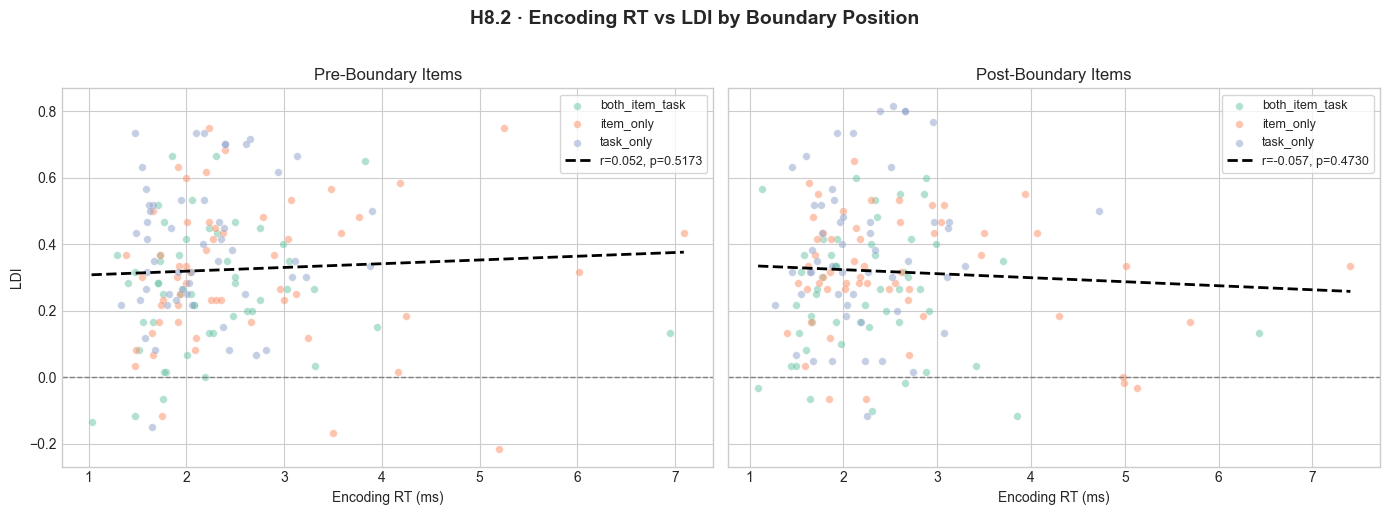

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("H8.2 · Encoding RT vs LDI by Boundary Position",
             fontsize=14, fontweight="bold", y=1.02)

for idx, pos in enumerate(rt_order):
    ax = axes[idx]
    sub = med_df[med_df["boundary_position"] == pos]
    for cond in cond_order:
        csub = sub[sub["condition"] == cond]
        ax.scatter(csub["Encoding_RT"], csub["LDI"], alpha=0.5, s=30,
                   color=cond_colors[cond], label=cond, edgecolors="white", linewidth=0.3)
    # regression line for this position
    if len(sub) >= 2 and sub["Encoding_RT"].nunique() > 1:
        slope, intercept, r, p, se = stats.linregress(sub["Encoding_RT"], sub["LDI"])
        xs = np.linspace(sub["Encoding_RT"].min(), sub["Encoding_RT"].max(), 100)
        ax.plot(xs, slope * xs + intercept, linewidth=2, color="black", linestyle="--",
                label=f"r={r:.3f}, p={p:.4f}")
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{pos}-Boundary Items", fontsize=12)
    ax.set_xlabel("Encoding RT (ms)")
    if idx == 0:
        ax.set_ylabel("LDI")
    ax.legend(frameon=True, fontsize=9, loc="best")

plt.tight_layout()
plt.show()

### 6. Mediation Path Diagram
Visual summary of the mediation paths (a, b, c', indirect) with coefficients and significance.

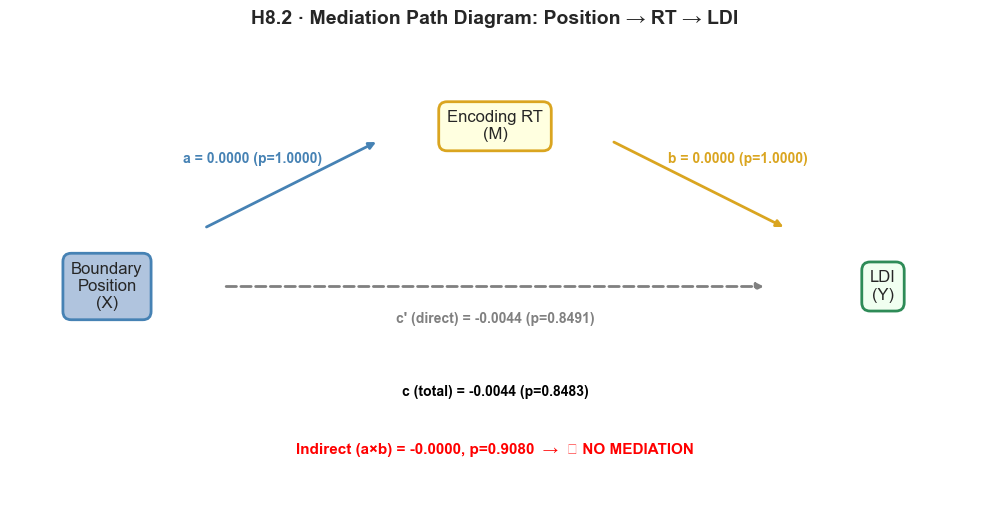

In [11]:
if med_results is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("H8.2 · Mediation Path Diagram: Position → RT → LDI",
                 fontsize=14, fontweight="bold", y=1.02)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")

    # Boxes
    box_style = dict(boxstyle="round,pad=0.5", facecolor="lightsteelblue", edgecolor="steelblue", linewidth=2)
    med_box   = dict(boxstyle="round,pad=0.5", facecolor="lightyellow",    edgecolor="goldenrod",  linewidth=2)
    out_box   = dict(boxstyle="round,pad=0.5", facecolor="honeydew",       edgecolor="seagreen",   linewidth=2)

    ax.text(1, 3, "Boundary\nPosition\n(X)", fontsize=12, ha="center", va="center", bbox=box_style)
    ax.text(5, 5.2, "Encoding RT\n(M)", fontsize=12, ha="center", va="center", bbox=med_box)
    ax.text(9, 3, "LDI\n(Y)", fontsize=12, ha="center", va="center", bbox=out_box)

    # Get coefficients
    coefs = dict(zip(med_results["path"], med_results["coef"]))
    pvals = dict(zip(med_results["path"], med_results["pval"]))

    def _fmt(path_name):
        c = coefs.get(path_name, 0)
        p = pvals.get(path_name, 1)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        return f"{c:.4f}{sig} (p={p:.4f})"

    # Path a: X → M
    ax.annotate("", xy=(3.8, 5.0), xytext=(2.0, 3.8),
                arrowprops=dict(arrowstyle="-|>", lw=2, color="steelblue"))
    ax.text(2.5, 4.7, f"a = {_fmt('X → M')}", fontsize=10, color="steelblue",
            ha="center", fontweight="bold")

    # Path b: M → Y
    ax.annotate("", xy=(8.0, 3.8), xytext=(6.2, 5.0),
                arrowprops=dict(arrowstyle="-|>", lw=2, color="goldenrod"))
    ax.text(7.5, 4.7, f"b = {_fmt('M → Y')}", fontsize=10, color="goldenrod",
            ha="center", fontweight="bold")

    # Path c' (direct): X → Y
    ax.annotate("", xy=(7.8, 3.0), xytext=(2.2, 3.0),
                arrowprops=dict(arrowstyle="-|>", lw=2, color="gray", linestyle="dashed"))
    ax.text(5, 2.5, f"c' (direct) = {_fmt('Direct')}", fontsize=10, color="gray",
            ha="center", fontweight="bold")

    # Path c (total): below
    ax.text(5, 1.5, f"c (total) = {_fmt('Total')}", fontsize=10, color="black",
            ha="center", fontweight="bold")

    # Indirect
    indirect_coef = coefs.get("Indirect", 0)
    indirect_p = pvals.get("Indirect", 1)
    indirect_sig = "✅ MEDIATION" if indirect_p < 0.05 else "❌ NO MEDIATION"
    ax.text(5, 0.7, f"Indirect (a×b) = {indirect_coef:.4f}, p={indirect_p:.4f}  →  {indirect_sig}",
            fontsize=11, ha="center", fontweight="bold",
            color="green" if indirect_p < 0.05 else "red")

    plt.tight_layout()
    plt.show()
else:
    print("  ⚠️  Skipping mediation diagram (no results).")